# Análisis y Visualización de Datos - Salar de Olaroz

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [2]:
cwd_parent = Path.cwd().parent
DATASET = cwd_parent / "tables" / "olaroz_samples_pixels_raw.csv"

In [3]:
# Fallback para ejecución local si se copió el CSV junto al notebook.
if not DATASET.exists():
    DATASET = Path("olaroz_samples_pixels_raw.csv")

In [4]:
# Carga
df = pd.read_csv(DATASET)
print("Dimensiones:", df.shape)
display(df.head())

Dimensiones: (21507, 22)


,sample_id,class_id,class_name,macro_class,season,confidence,split,source,notes,scl,...,B04,B03,B02,B05,B06,B07,B08,B8A,B11,B12
0,agua_humedad_001,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,5,...,2964.0,6494.0,6716.0,2251.5,1170.0,1171.0,1153.5,1122.0,1114.0,1096.5
1,agua_humedad_001,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,5,...,2814.0,6524.0,6694.0,2159.0,1134.5,1153.0,1129.5,1097.5,1110.0,1109.5
2,agua_humedad_001,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,5,...,2873.0,6542.0,6806.0,2193.0,1140.0,1149.5,1138.5,1099.0,1106.0,1104.0
3,agua_humedad_001,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,5,...,2967.0,6574.0,6802.0,2277.5,1155.5,1172.5,1150.5,1110.5,1098.5,1085.5
4,agua_humedad_001,3,agua_humedad,humedad_agua,seca,alta,train,sentinel2_l2a_2025,zona oscura homogénea asociada a humedad super...,6,...,3115.0,6670.0,6864.0,2370.0,1175.5,1177.0,1168.5,1128.0,1095.5,1078.0


In [5]:
# Familias de columnas
id_cols = ["sample_id", "class_id", "class_name", "macro_class", "season", "confidence", "split", "source", "notes", "scl"]
coord_cols = ["x", "y"]
band_cols = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]

In [6]:
# 1. Auditoría mínima de estructura
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_pct": (df.isna().mean() * 100).round(3),
    "unicos": df.nunique(),
})
display(schema)

,dtype,nulos,nulos_pct,unicos
sample_id,str,0,0.0,70
class_id,int64,0,0.0,4
class_name,str,0,0.0,4
macro_class,str,0,0.0,3
season,str,0,0.0,1
confidence,str,0,0.0,1
split,str,0,0.0,3
source,str,0,0.0,1
notes,str,0,0.0,5
scl,int64,0,0.0,6


In [7]:
# 2. Distribución por clase: píxeles vs sample_id
class_pixels = df["class_name"].value_counts().rename("pixeles")
class_samples = df.groupby("class_name")["sample_id"].nunique().rename("sample_id")
display(pd.concat([class_pixels, class_samples], axis=1))

,pixeles,sample_id
class_name,,
salina,7575,20
agua_humedad,6771,20
suelo_rocoso,4432,10
suelo_desnudo,2729,20


In [8]:
# 3. Tamaño de cada sample_id
sample_sizes = df.groupby(["sample_id", "class_name", "split"]).size().reset_index(name="n_pixels")
display(sample_sizes.groupby("class_name")["n_pixels"].describe())

,count,mean,std,min,25%,50%,75%,max
class_name,,,,,,,,
agua_humedad,20.0,338.55,226.522794,27.0,172.25,341.0,479.75,861.0
salina,20.0,378.75,209.809908,60.0,210.00,356.5,548.00,763.0
suelo_desnudo,20.0,136.45,111.064455,24.0,54.25,109.5,154.25,433.0
suelo_rocoso,10.0,443.20,242.013682,209.0,287.50,313.5,567.75,928.0


In [9]:
# 4. Split analizado por píxeles y por sample_id
print("Split por píxeles")
display(pd.crosstab(df["split"], df["class_name"], margins=True))
print("Split por sample_id")
display(pd.crosstab(df.drop_duplicates("sample_id")["split"], df.drop_duplicates("sample_id")["class_name"], margins=True))

Split por píxeles


class_name,agua_humedad,salina,suelo_desnudo,suelo_rocoso,All
split,,,,,
test,140,1016,194,584,1934
train,6128,5453,2346,3356,17283
validation,503,1106,189,492,2290
All,6771,7575,2729,4432,21507


Split por sample_id


class_name,agua_humedad,salina,suelo_desnudo,suelo_rocoso,All
split,,,,,
test,3,3,3,2,11
train,14,14,14,7,49
validation,3,3,3,1,10
All,20,20,20,10,70


In [10]:
# 5. Control de SCL por clase
# SCL debe interpretarse como control/mascara auxiliar, no como etiqueta final.
display(pd.crosstab(df["scl"], df["class_name"], margins=True))

class_name,agua_humedad,salina,suelo_desnudo,suelo_rocoso,All
scl,,,,,
2,0,0,0,5,5
5,172,0,2729,4427,7328
6,6545,0,0,0,6545
7,1,0,0,0,1
8,18,0,0,0,18
11,35,7575,0,0,7610
All,6771,7575,2729,4432,21507


In [11]:
# 6. Índices exploratorios calculados desde bandas crudas
# No reemplazan al dataset features; se usan aquí para visualización y formulación de hipótesis.
def ndi(a, b):
    denom = a + b
    return np.where(denom != 0, (a - b) / denom, np.nan)

In [12]:
df["NDVI"] = ndi(df["B08"], df["B04"])
df["NDWI"] = ndi(df["B03"], df["B08"])
df["MNDWI"] = ndi(df["B03"], df["B11"])
df["NDBI_like"] = ndi(df["B11"], df["B08"])

In [13]:
# 7. Figuras básicas
FIGURES_DIR = Path("reports") / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [14]:
colors = {
    "agua_humedad": "#1f77b4",
    "salina": "#9467bd",
    "suelo_desnudo": "#d99027",
    "suelo_rocoso": "#4d4d4d",
}
classes = ["agua_humedad", "salina", "suelo_desnudo", "suelo_rocoso"]

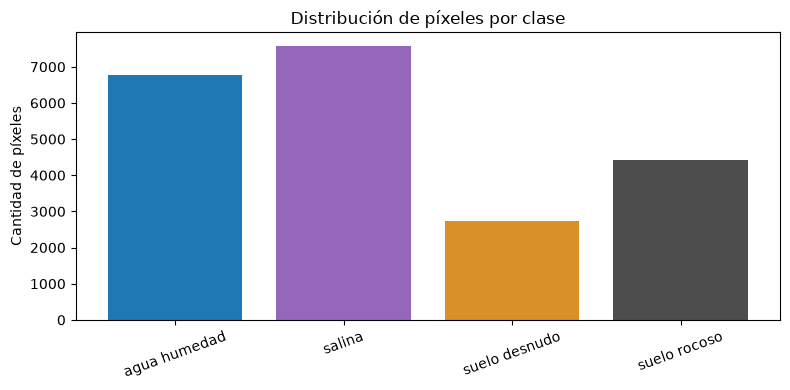

In [15]:
# Distribución de clases
fig, ax = plt.subplots(figsize=(8, 4))
counts = df["class_name"].value_counts().reindex(classes)
ax.bar([c.replace("_", " ") for c in classes], counts.values, color=[colors[c] for c in classes])
ax.set_title("Distribución de píxeles por clase")
ax.set_ylabel("Cantidad de píxeles")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=180)
plt.show()

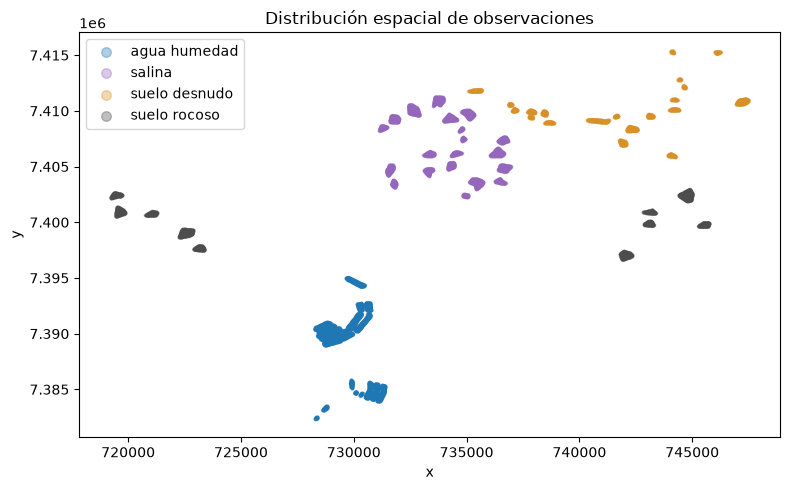

In [16]:
# Distribución espacial
fig, ax = plt.subplots(figsize=(8, 5))
for c in classes:
    sub = df[df["class_name"] == c]
    ax.scatter(sub["x"], sub["y"], s=3, alpha=0.35, color=colors[c], label=c.replace("_", " "))
ax.set_title("Distribución espacial de observaciones")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "spatial_distribution.png", dpi=180)
plt.show()

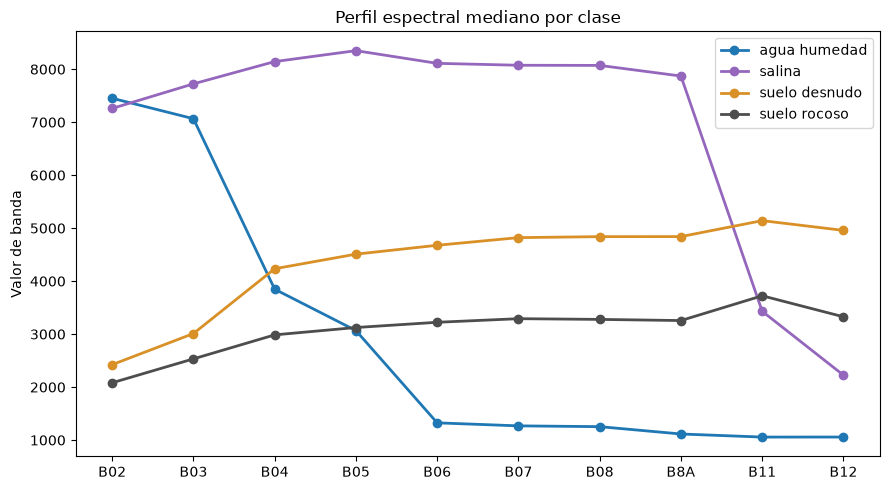

In [17]:
# Perfil espectral por clase
profile = df.groupby("class_name")[band_cols].median().reindex(classes)
fig, ax = plt.subplots(figsize=(9, 5))
for c in classes:
    ax.plot(band_cols, profile.loc[c], marker="o", linewidth=2, color=colors[c], label=c.replace("_", " "))
ax.set_title("Perfil espectral mediano por clase")
ax.set_ylabel("Valor de banda")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "spectral_profile.png", dpi=180)
plt.show()

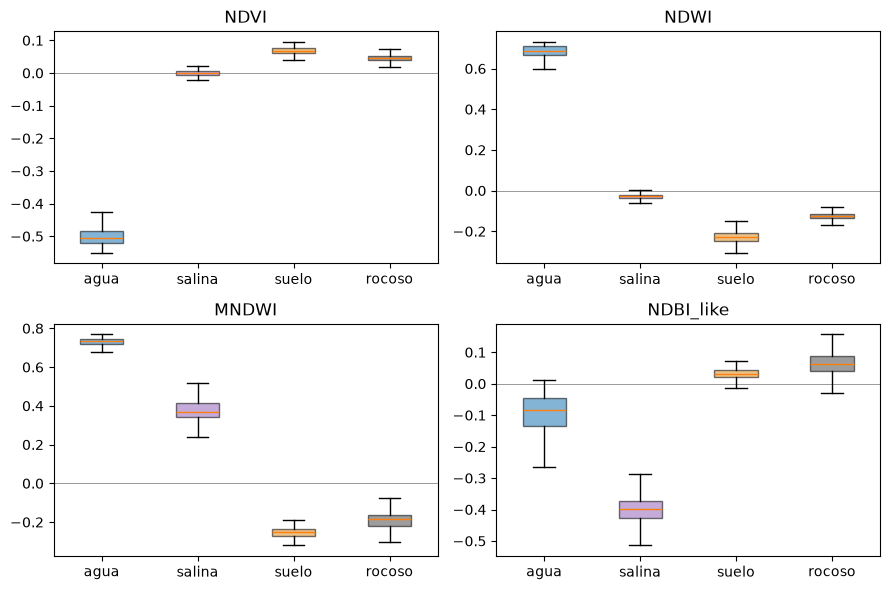

In [19]:
# Índices exploratorios
indices = ["NDVI", "NDWI", "MNDWI", "NDBI_like"]
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for ax, ind in zip(axes.ravel(), indices):
    data = [df[df["class_name"] == c][ind].dropna().values for c in classes]
    bp = ax.boxplot(data, patch_artist=True, tick_labels=["agua", "salina", "suelo", "rocoso"], showfliers=False)
    for patch, c in zip(bp["boxes"], classes):
        patch.set_facecolor(colors[c])
        patch.set_alpha(0.55)
    ax.set_title(ind)
    ax.axhline(0, color="black", linewidth=0.7, alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "indices_boxplots.png", dpi=180)
plt.show()

In [20]:
# 8. Recomendaciones hacia ML supervisado, sin entrenar todavía.
non_predictors = [
    "sample_id", "class_id", "class_name", "macro_class", "season", "confidence", "split", "source", "notes"
]
print("Columnas que no deberían entrar directamente como predictores:")
print(non_predictors)

print("\nIdea clave:")
print("sample_id debe usarse como unidad de agrupación para dividir train/test; no debe mezclarse un mismo sample_id entre conjuntos.")

Columnas que no deberían entrar directamente como predictores:
['sample_id', 'class_id', 'class_name', 'macro_class', 'season', 'confidence', 'split', 'source', 'notes']

Idea clave:
sample_id debe usarse como unidad de agrupación para dividir train/test; no debe mezclarse un mismo sample_id entre conjuntos.
